In [3]:
!pip install wordcloud -q

C:\Users\danie\AppData\Local\Temp\ipykernel_5512\1679264364.py:12: DtypeWarning: Columns (39) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"F:\Datasets_Project\CICIoT2023\Attacks\processed\CICIoT2023_balanced_packetdata.csv")


Generating word clouds from CSV data...


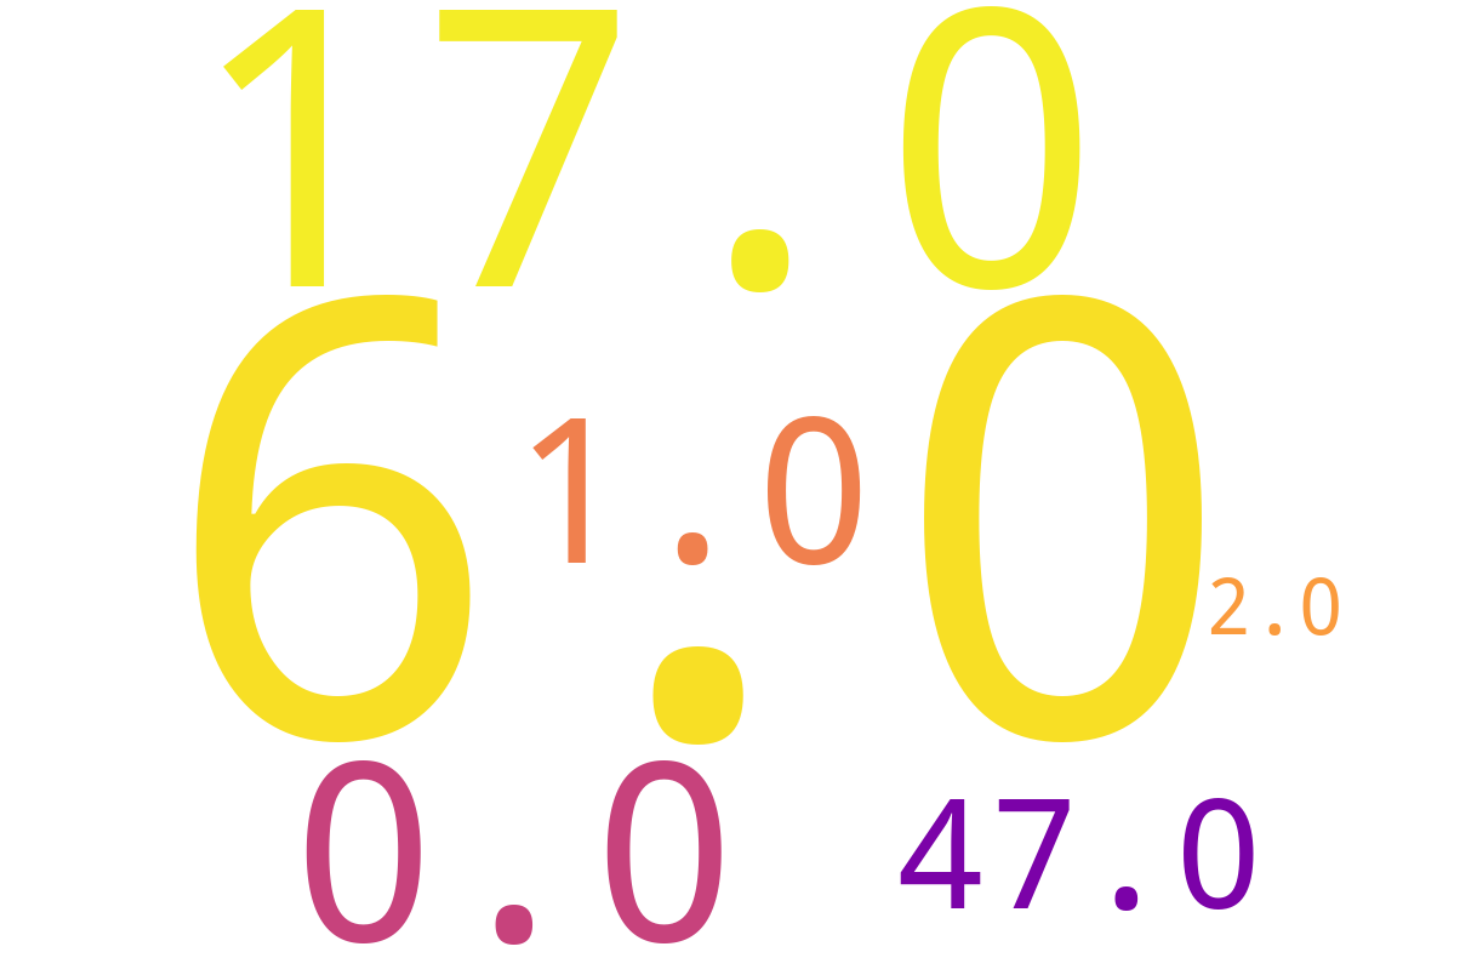

Saved: Network_Devices_Word_Cloud.pdf


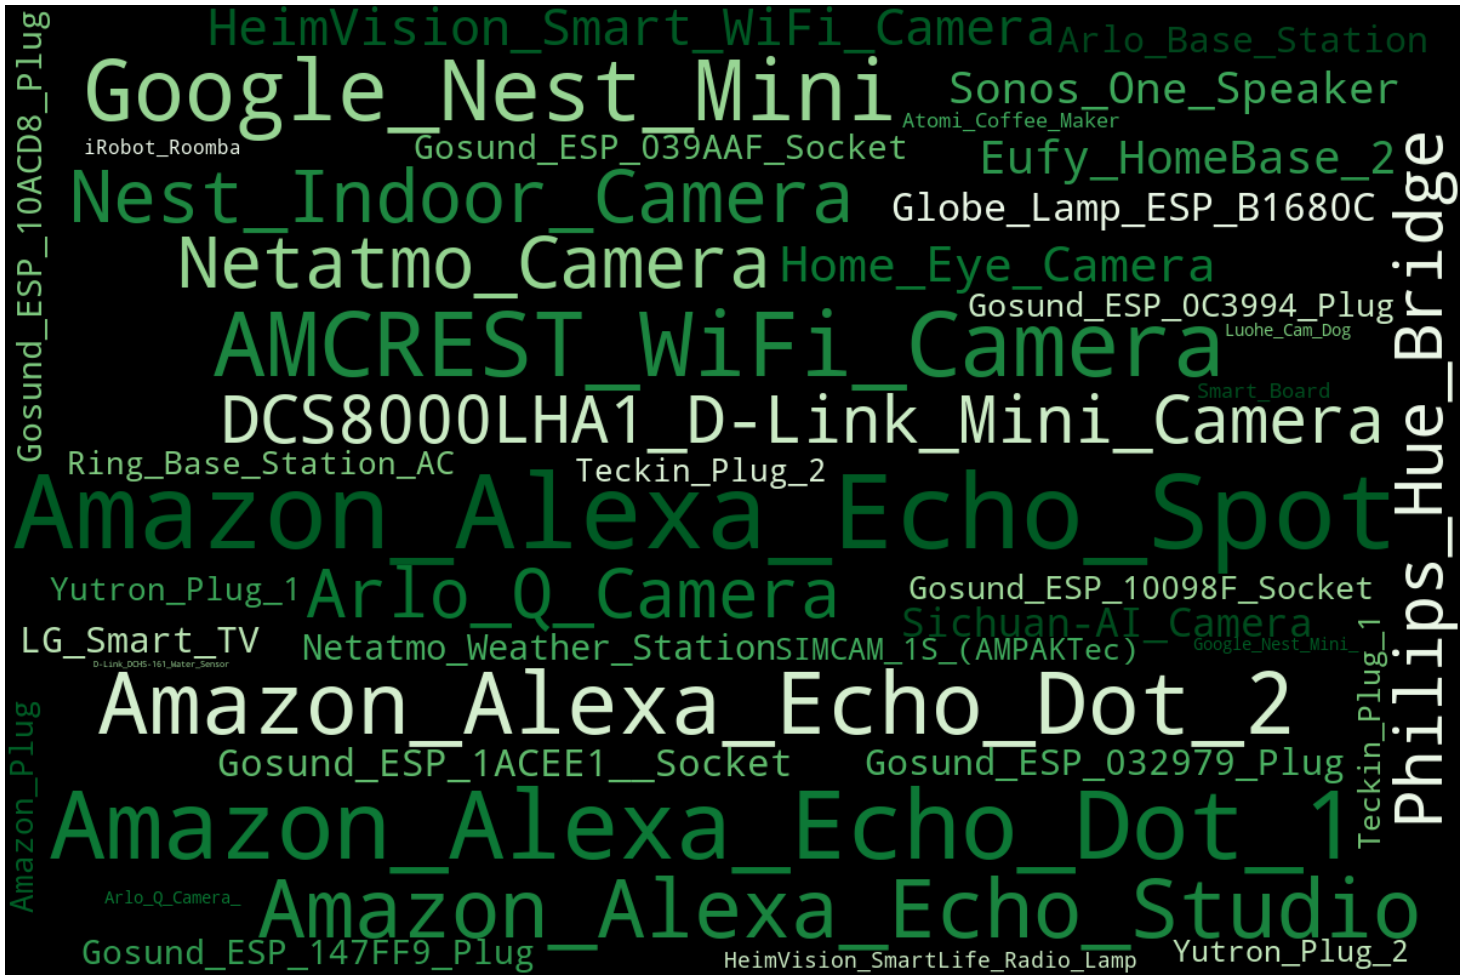

Saved: Network Traffic Types_Attacks Word Cloud.pdf


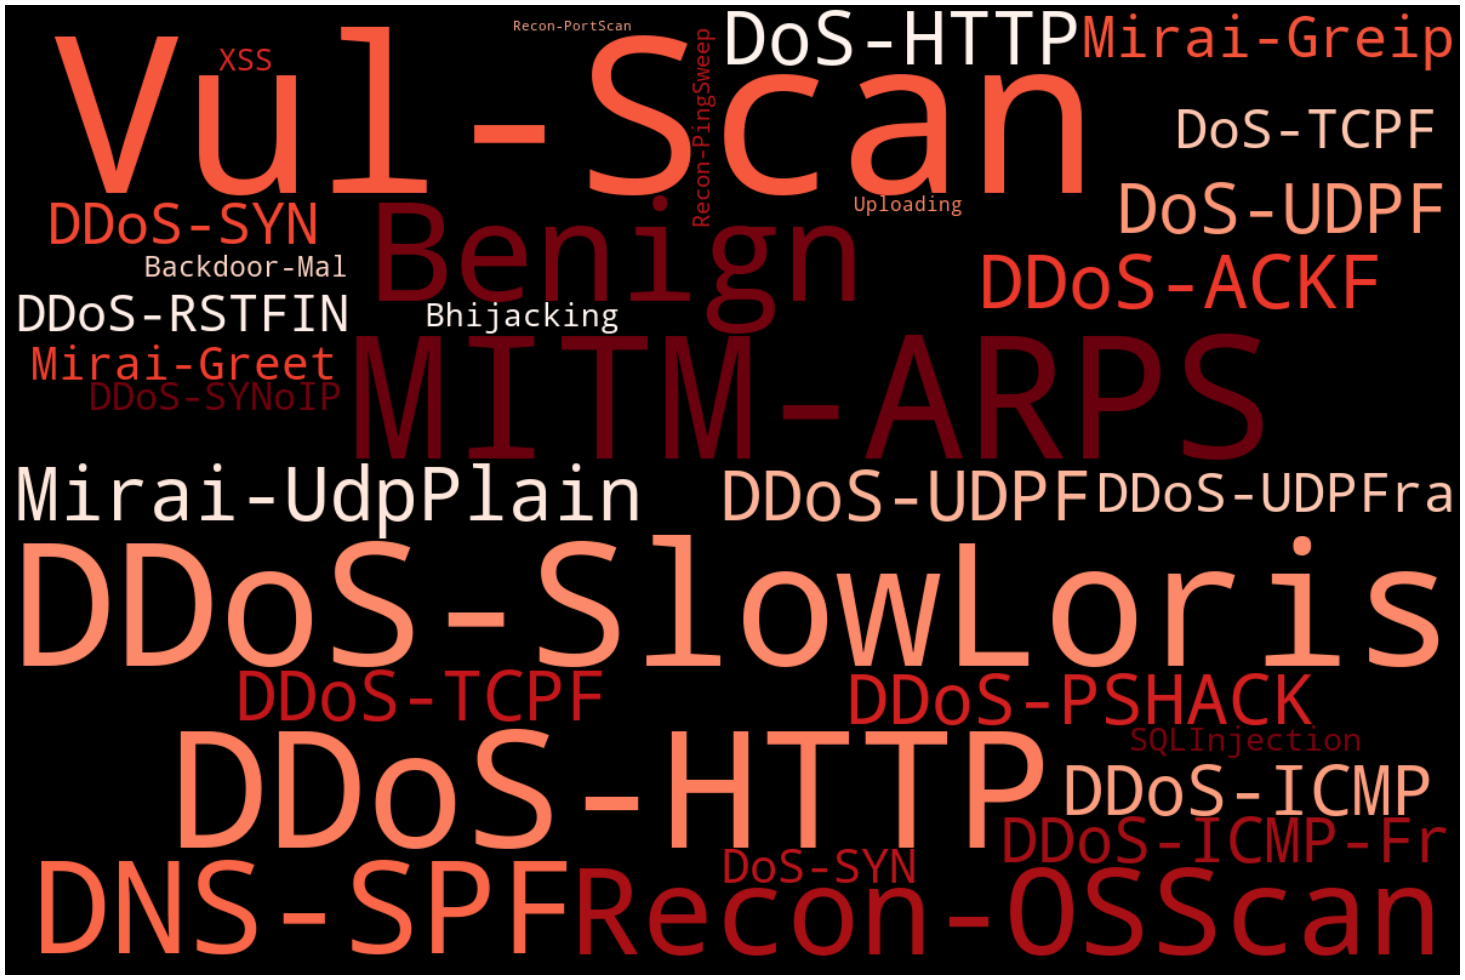

In [4]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages
import scienceplots
plt.style.use(['science', 'notebook', 'grid', 'no-latex'])

# Read CSV file
# Read CSV file
df = pd.read_csv(r"F:\Datasets_Project\CICIoT2023\Attacks\processed\CICIoT2023_balanced_packetdata.csv")

# Replace spaces in 'Label' column to treat multi-word labels as one word
df['Label'] = df['Label'].astype(str).str.replace(' ', '_', regex=False)
df['Traffic Type'] = df['Traffic Type'].astype(str).str.replace(' ', '_', regex=False)


# Function to create and display word cloud
def generate_wordcloud(data_column,  colormap='viridis', background_color='white', save_as_pdf=None): #title,
    # Count frequencies (handling NaN values)
    text_data = ' '.join([str(x) for x in data_column.dropna()])
    word_freq = Counter(text_data.split())

    if not word_freq:
        #print(f"No data available for {}")
        return

    # Create word cloud
    wc = WordCloud(width=1200, height=800,
                  background_color=background_color,
                  colormap=colormap,
                  max_words=100,
                  contour_width=3,
                  contour_color='steelblue').generate_from_frequencies(word_freq)

    # Display
    plt.figure(figsize=(15, 10))
    plt.imshow(wc, interpolation='bilinear')
    #plt.title(title, fontsize=20, pad=20)
    plt.axis("off")
    plt.tight_layout()

    # Save to PDF if filename is provided
    if save_as_pdf:
        with PdfPages(save_as_pdf) as pdf:
            pdf.savefig(plt.gcf(), bbox_inches='tight')  # Save current figure
        print(f"Saved: {save_as_pdf}")

    plt.show()
    return wc

# Generate all word clouds
print("Generating word clouds from CSV data...")

# 1. Protocol IP Word Cloud
generate_wordcloud(df['Protocol_IP'],
                  #"Network Protocols Word Cloud",
                  colormap='plasma')

# 2. Device Labels Word Cloud
generate_wordcloud(df['Label'],
                  #"Network Devices Word Cloud",
                  colormap='Greens',
                   background_color='black', 
                   save_as_pdf="Network_Devices_Word_Cloud.pdf")

# 3. Traffic Type/Attacks Word Cloud
generate_wordcloud(df['Traffic Type'],
                  #"Network Traffic Types/Attacks Word Cloud",
                  colormap='Reds',
                  background_color='black', save_as_pdf="Network Traffic Types_Attacks Word Cloud.pdf")

Generating word clouds from CSV data...


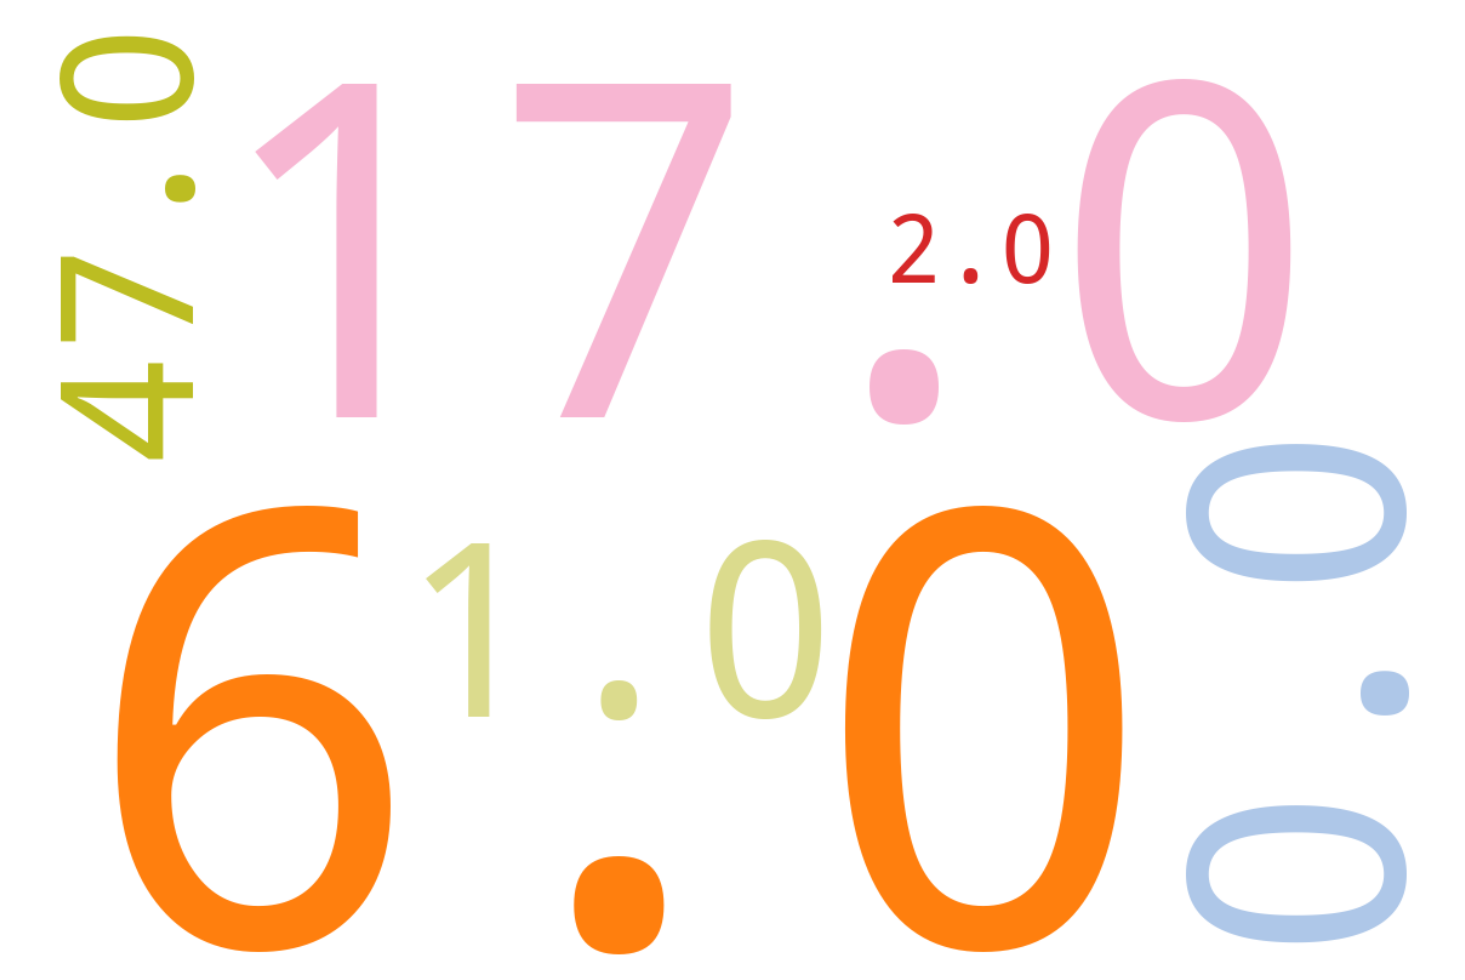

Saved: Network_Devices_Word_Cloud_.pdf


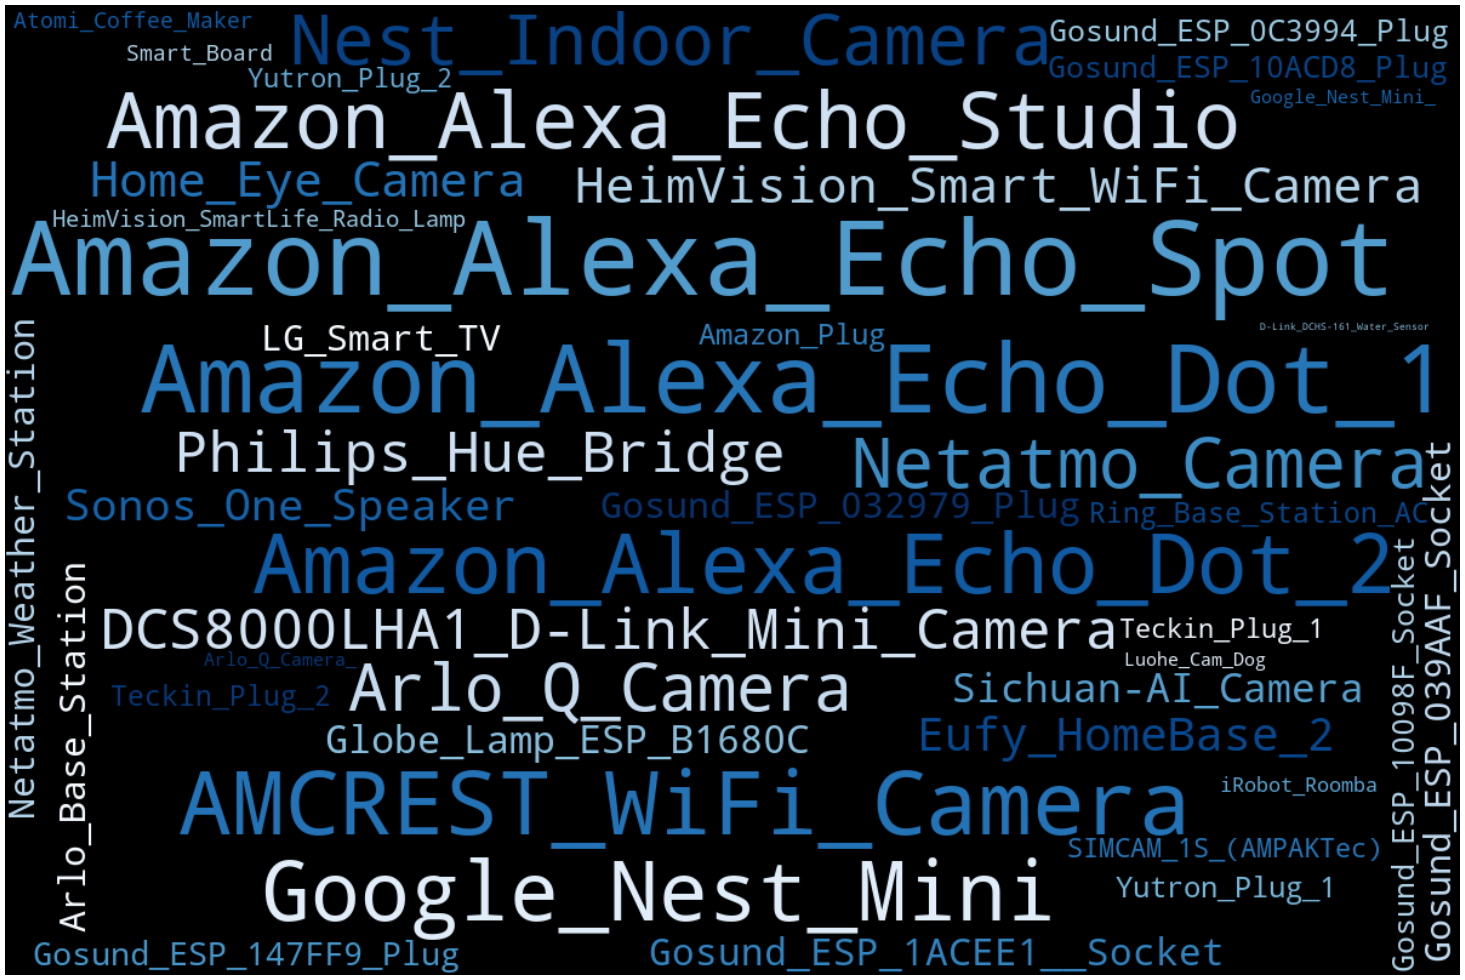

Saved: Network Traffic Types_Attacks Word Cloud_.pdf


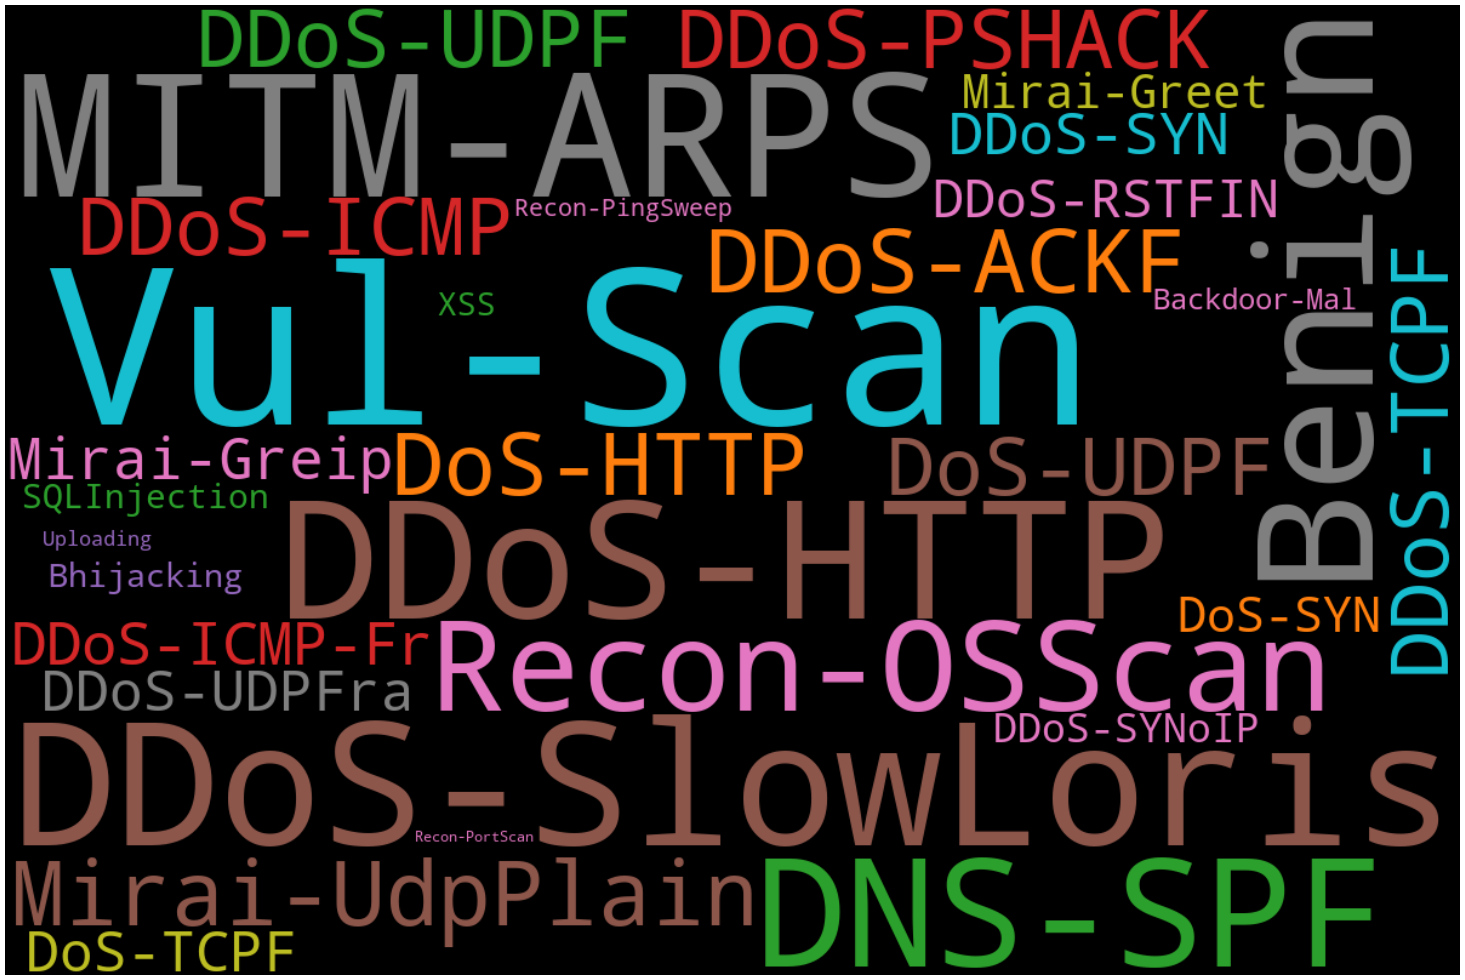

In [5]:
# Function to create and display word cloud
def generate_wordcloud(data_column,  colormap='viridis', background_color='white', save_as_pdf=None): #title,
    # Count frequencies (handling NaN values)
    text_data = ' '.join([str(x) for x in data_column.dropna()])
    word_freq = Counter(text_data.split())

    if not word_freq:
        #print(f"No data available for {}")
        return

    # Create word cloud
    wc = WordCloud(width=1200, height=800,
                  background_color=background_color,
                  colormap=colormap,
                  max_words=100,
                  contour_width=3,
                  contour_color='steelblue').generate_from_frequencies(word_freq)

    # Display
    plt.figure(figsize=(15, 10))
    plt.imshow(wc, interpolation='bilinear')
    #plt.title(title, fontsize=20, pad=20)
    plt.axis("off")
    plt.tight_layout()

    # Save to PDF if filename is provided
    if save_as_pdf:
        with PdfPages(save_as_pdf) as pdf:
            pdf.savefig(plt.gcf(), bbox_inches='tight')  # Save current figure
        print(f"Saved: {save_as_pdf}")

    plt.show()
    return wc

# Generate all word clouds
print("Generating word clouds from CSV data...")

# 1. Protocol IP Word Cloud
generate_wordcloud(df['Protocol_IP'],
                  #"Network Protocols Word Cloud",
                  colormap='tab20')

# 2. Device Labels Word Cloud
generate_wordcloud(df['Label'],
                  #"Network Devices Word Cloud",
                  colormap='Blues',
                   background_color='black', 
                   save_as_pdf="Network_Devices_Word_Cloud_.pdf")

# 3. Traffic Type/Attacks Word Cloud
generate_wordcloud(df['Traffic Type'],
                  #"Network Traffic Types/Attacks Word Cloud",
                  colormap='tab10',
                  background_color='black', save_as_pdf="Network Traffic Types_Attacks Word Cloud_.pdf")